In [1]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load MEG data
fname = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"
raw = mne.io.read_raw_fif(fname, preload=True)
raw.filter(1., 40.)

# Load behavioral data
df_behav = pd.read_csv('/Users/roman/PycharmProjects/brain_data/data/15.10.24/1/alena_final_untitled_2024-10-15_13h00.00.308.csv')

# Extract start times
fix_cross_start = df_behav['fix_cross.started'].dropna().values
print(f"Loaded {len(fix_cross_start)} fixation cross starts")
print(f"MEG data duration: {raw.times[-1]:.2f} seconds")

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

In [2]:
def extract_windows(raw, event_times, window_duration=2.0, pre_event=0.5, fs=1000):
    """
    Extract windows around event times

    Parameters:
    - window_duration: total window length in seconds
    - pre_event: seconds before event to include (event at pre_event seconds into window)
    - fs: sampling rate after resampling

    Returns:
    - X: array of shape (n_windows, n_timepoints, n_channels)
    - y: array of event offsets within window (0 to window_duration)
    """
    # Resample to fixed fs
    raw_resampled = raw.copy().resample(fs, npad='auto')
    data, times = raw_resampled[:, :]

    n_samples_window = int(window_duration * fs)
    pre_samples = int(pre_event * fs)

    X = []
    y = []

    for event_time in event_times:
        # Find sample index of event
        event_idx = np.argmin(np.abs(times - event_time))

        # Window start: event_time - pre_event
        start_idx = event_idx - pre_samples

        # Check bounds
        if start_idx >= 0 and start_idx + n_samples_window <= data.shape[1]:
            window = data[:, start_idx:start_idx + n_samples_window].T  # (time, channels)
            X.append(window)
            y.append(pre_event)  # Event is exactly at pre_event seconds into window
        else:
            print(f"Warning: Event at {event_time:.2f}s too close to edge, skipping")

    return np.array(X), np.array(y)

# Extract windows
window_duration = 2.0  # 2 second windows
pre_event = 0.5        # Event at 0.5s into window

X, y = extract_windows(raw, fix_cross_start, window_duration, pre_event)
print(f"Extracted {len(X)} windows")
print(f"X shape: {X.shape}")  # (n_windows, n_timepoints, n_channels)
print(f"y shape: {y.shape}")  # (n_windows,) - all 0.5s

Sampling frequency of the instance is already 1000.0, returning unmodified.
Extracted 808 windows
X shape: (808, 2000, 324)
y shape: (808,)


In [3]:
def extract_simple_features(X, fs=1000):
    """
    Extract handcrafted features from MEG windows
    Returns: (n_windows, n_features)
    """
    n_windows, n_timepoints, n_channels = X.shape

    features = []

    for i in range(n_windows):
        window = X[i]  # (time, channels)
        feat = []

        # 1. Basic statistics per channel
        for ch in range(n_channels):
            feat.append(np.mean(window[:, ch]))
            feat.append(np.std(window[:, ch]))
            feat.append(np.max(window[:, ch]) - np.min(window[:, ch]))

        # 2. Temporal features (mean across channels)
        mean_signal = np.mean(window, axis=1)  # (time,)
        feat.append(np.mean(mean_signal))
        feat.append(np.std(mean_signal))

        # 3. Simple frequency features
        fft_vals = np.abs(np.fft.rfft(mean_signal))
        feat.append(np.mean(fft_vals[1:20]))  # Low frequency power
        feat.append(np.argmax(fft_vals[1:20]))  # Peak frequency index

        # 4. Derivative (rate of change)
        diff = np.diff(mean_signal)
        feat.append(np.mean(np.abs(diff)))
        feat.append(np.std(diff))

        features.append(feat)

    return np.array(features)

# Extract features
print("Extracting features...")
X_features = extract_simple_features(X)
print(f"Features shape: {X_features.shape}")

Extracting features...
Features shape: (808, 978)


In [4]:
# Cell 4 (Fast version)
def create_balanced_dataset_fast(raw, event_times, window_duration=2.0, fs=250, n_negatives=200):
    """
    FASTER: Lower sampling rate, fewer negatives, vectorized checks
    """
    # Use lower sampling rate (250Hz instead of 1000Hz)
    raw_resampled = raw.copy().resample(fs, npad='auto')
    data, times = raw_resampled[:, :]

    n_samples_window = int(window_duration * fs)
    pre_samples = int(0.5 * fs)

    # Positive windows
    X_pos = []
    for event_time in event_times[:200]:  # Limit to first 200 events
        event_idx = np.argmin(np.abs(times - event_time))
        start_idx = event_idx - pre_samples
        if start_idx >= 0 and start_idx + n_samples_window <= data.shape[1]:
            window = data[:, start_idx:start_idx + n_samples_window].T
            X_pos.append(window)

    X_pos = np.array(X_pos)
    y_pos = np.ones(len(X_pos)) * 0.5

    # Negative windows (fast using numpy)
    event_samples = set([np.argmin(np.abs(times - et)) for et in event_times[:200]])
    event_mask = np.zeros(data.shape[1], dtype=bool)
    margin = int(0.1 * fs)
    for e in event_samples:
        event_mask[max(0, e-margin):min(len(event_mask), e+margin)] = True

    X_neg = []
    attempts = 0
    while len(X_neg) < n_negatives and attempts < n_negatives * 5:
        start_idx = np.random.randint(0, data.shape[1] - n_samples_window)
        if not event_mask[start_idx:start_idx + n_samples_window].any():
            X_neg.append(data[:, start_idx:start_idx + n_samples_window].T)
        attempts += 1

    X_neg = np.array(X_neg)
    y_neg = np.zeros(len(X_neg))

    # Combine
    X_combined = np.vstack([X_pos, X_neg])
    y_combined = np.concatenate([y_pos, y_neg])
    idx = np.random.permutation(len(X_combined))

    return X_combined[idx], y_combined[idx]

# Run it
# print("Creating balanced dataset (fast version)...")
# X_balanced, y_balanced = create_balanced_dataset_fast(
#     raw, fix_cross_start,
#     fs=250,  # Lower sampling rate = 4x faster
#     n_negatives=200
# )
# print(f"Done! {len(X_balanced)} windows")
# print(f"X shape: {X_balanced.shape}")  # (n_windows, 500 timepoints, n_channels)

# Create balanced dataset
print("Creating balanced dataset...")
X_balanced, y_balanced = create_balanced_dataset_fast(raw, fix_cross_start, n_negatives=len(fix_cross_start)*2)
print(f"Balanced dataset: {len(X_balanced)} windows")
print(f"Positive: {np.sum(y_balanced > 0)}, Negative: {np.sum(y_balanced == 0)}")

# Extract features
X_features_balanced = extract_simple_features(X_balanced)
print(f"Features shape: {X_features_balanced.shape}")

Creating balanced dataset (fast version)...
Finding events on: STI101
805 events found on stim channel STI101
Event IDs: [8]
Finding events on: STI101
805 events found on stim channel STI101
Event IDs: [8]
Done! 400 windows
X shape: (400, 500, 324)
Creating balanced dataset...
Finding events on: STI101
805 events found on stim channel STI101
Event IDs: [8]
Finding events on: STI101
805 events found on stim channel STI101
Event IDs: [8]
Balanced dataset: 1816 windows
Positive: 200, Negative: 1616
Features shape: (1816, 978)


In [5]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_features_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced > 0
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest
print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# Predict
y_pred = rf.predict(X_test_scaled)

# Evaluate
from sklearn.metrics import mean_absolute_error, r2_score

# Only evaluate on positive samples (where y_test > 0)
positive_mask = y_test > 0
if np.sum(positive_mask) > 0:
    mae = mean_absolute_error(y_test[positive_mask], y_pred[positive_mask])
    print(f"MAE on positive samples: {mae*1000:.1f} ms")

    # Count how many predictions are close
    within_50ms = np.mean(np.abs(y_test[positive_mask] - y_pred[positive_mask]) < 0.05)
    within_100ms = np.mean(np.abs(y_test[positive_mask] - y_pred[positive_mask]) < 0.1)
    print(f"Within 50ms: {within_50ms*100:.1f}%")
    print(f"Within 100ms: {within_100ms*100:.1f}%")

Training Random Forest...
MAE on positive samples: 253.2 ms
Within 50ms: 5.0%
Within 100ms: 22.5%


In [6]:
def predict_event_timestamps(raw, model, scaler, window_duration=2.0, stride=0.5, fs=1000, threshold=0.3):
    """
    Slide window over entire recording and predict event timestamps
    """
    raw_resampled = raw.copy().resample(fs, npad='auto')
    data, times = raw_resampled[:, :]

    n_samples_window = int(window_duration * fs)
    n_samples_stride = int(stride * fs)

    predictions = []  # (time, confidence)

    for start_idx in range(0, data.shape[1] - n_samples_window, n_samples_stride):
        window = data[:, start_idx:start_idx + n_samples_window].T
        features = extract_simple_features(np.array([window]))
        features_scaled = scaler.transform(features)

        pred_time = model.predict(features_scaled)[0]

        if pred_time > threshold:  # Event detected
            absolute_time = times[start_idx] + pred_time
            predictions.append(absolute_time)

    # Merge nearby predictions
    merged = []
    for ts in sorted(predictions):
        if not merged or ts - merged[-1] > 0.4:  # 400ms minimum gap
            merged.append(ts)

    return merged

# Predict on first 60 seconds of data
print("Predicting events on first 60 seconds...")
raw_subset = raw.copy().crop(0, 60)
predicted_starts = predict_event_timestamps(raw_subset, rf, scaler)

print(f"\nPredicted {len(predicted_starts)} events")
print(f"First 5 predictions: {[f'{t:.2f}s' for t in predicted_starts[:5]]}")

# Compare with ground truth in first 60 seconds
true_in_range = fix_cross_start[(fix_cross_start >= 0) & (fix_cross_start <= 60)]
print(f"Ground truth in first 60s: {len(true_in_range)} events")
print(f"True times: {[f'{t:.2f}s' for t in true_in_range[:5]]}")

Predicting events on first 60 seconds...
Sampling frequency of the instance is already 1000.0, returning unmodified.

Predicted 0 events
First 5 predictions: []
Ground truth in first 60s: 8 events
True times: ['22.89s', '27.64s', '33.27s', '37.95s', '43.09s']


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


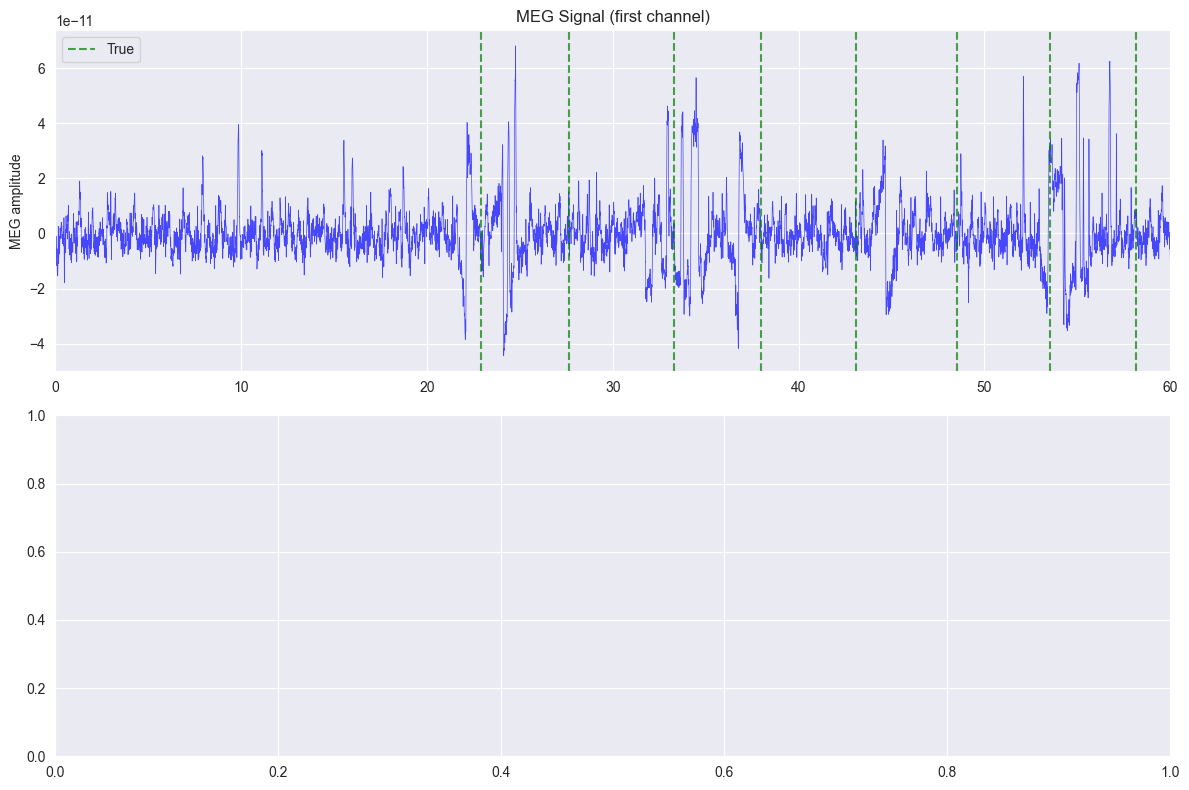

In [8]:
# Plot predictions vs ground truth for first 60 seconds
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# First 60 seconds of MEG data (first channel)
raw_subset = raw.copy().crop(0, 60).pick_channels([raw.ch_names[0]])
data, times = raw_subset[:, :]
axes[0].plot(times, data[0], 'b-', alpha=0.7, linewidth=0.5)
axes[0].set_ylabel('MEG amplitude')
axes[0].set_title('MEG Signal (first channel)')

# Mark events
true_in_range = fix_cross_start[(fix_cross_start >= 0) & (fix_cross_start <= 60)]
for t in true_in_range:
    axes[0].axvline(x=t, color='g', linestyle='--', alpha=0.7, label='True' if t == true_in_range[0] else '')

for t in predicted_starts:
    axes[0].axvline(x=t, color='r', linestyle=':', alpha=0.7, label='Predicted' if t == predicted_starts[0] else '')

axes[0].legend()
axes[0].set_xlim(0, 60)

# Histogram of errors (for overlapping predictions)
if len(predicted_starts) > 0 and len(true_in_range) > 0:
    # Match predictions to nearest true events
    errors = []
    for pred in predicted_starts:
        nearest_true = min(true_in_range, key=lambda x: abs(x - pred))
        if abs(pred - nearest_true) < 0.5:  # Within 500ms
            errors.append(pred - nearest_true)

    axes[1].hist(errors, bins=20, color='steelblue', edgecolor='black')
    axes[1].axvline(x=0, color='r', linestyle='--')
    axes[1].set_xlabel('Prediction Error (seconds)')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f'Prediction Errors (mean = {np.mean(errors)*1000:.1f}ms, std = {np.std(errors)*1000:.1f}ms)')

plt.tight_layout()
plt.show()

In [9]:
def predict_event_timestamps(raw, model, scaler, window_duration=2.0, stride=0.2, fs=250, threshold=0.1):
    """
    Slide window over entire recording and predict event timestamps
    """
    raw_resampled = raw.copy().resample(fs, npad='auto')
    data, times = raw_resampled[:, :]

    n_samples_window = int(window_duration * fs)
    n_samples_stride = int(stride * fs)

    predictions = []  # (time, confidence)
    all_pred_times = []  # Store all predictions for debugging

    print(f"Scanning {data.shape[1]} samples with window size {n_samples_window}, stride {n_samples_stride}")

    for start_idx in range(0, data.shape[1] - n_samples_window, n_samples_stride):
        window = data[:, start_idx:start_idx + n_samples_window].T
        features = extract_simple_features(np.array([window]))
        features_scaled = scaler.transform(features)

        pred_time = model.predict(features_scaled)[0]
        all_pred_times.append(pred_time)

        if pred_time > threshold:  # Lowered threshold
            absolute_time = times[start_idx] + pred_time
            predictions.append(absolute_time)

    print(f"Mean prediction value: {np.mean(all_pred_times):.3f}")
    print(f"Predictions > {threshold}: {np.sum(np.array(all_pred_times) > threshold)}")

    # Merge nearby predictions
    if predictions:
        predictions.sort()
        merged = []
        for ts in predictions:
            if not merged or ts - merged[-1] > 0.4:  # 400ms minimum gap
                merged.append(ts)
        return merged
    else:
        return []

# Predict on first 60 seconds with lower threshold
print("Predicting events on first 60 seconds...")
raw_subset = raw.copy().crop(0, 60)
predicted_starts = predict_event_timestamps(raw_subset, rf, scaler, threshold=0.05)

print(f"\nPredicted {len(predicted_starts)} events")
print(f"Predictions: {[f'{t:.2f}s' for t in predicted_starts[:10]]}")

Predicting events on first 60 seconds...
Finding events on: STI101
8 events found on stim channel STI101
Event IDs: [8]
Finding events on: STI101
8 events found on stim channel STI101
Event IDs: [8]
Scanning 15000 samples with window size 500, stride 50
Mean prediction value: 0.082
Predictions > 0.05: 113

Predicted 51 events
Predictions: ['0.21s', '0.70s', '1.30s', '1.87s', '2.30s', '3.48s', '3.89s', '4.54s', '5.07s', '8.29s']


In [10]:
# Check if model is predicting anything at all
print("=== DEBUGGING MODEL OUTPUT ===")

# Test on a few known positive windows
print("\nTesting on positive windows:")
for i in range(min(3, len(X_balanced))):
    if y_balanced[i] > 0:  # Positive sample
        features = extract_simple_features(X_balanced[i].reshape(1, *X_balanced[i].shape))
        features_scaled = scaler.transform(features)
        pred = rf.predict(features_scaled)[0]
        true = y_balanced[i]
        print(f"  Sample {i}: True={true:.2f}, Pred={pred:.2f}, Diff={abs(pred-true)*1000:.0f}ms")

# Test on negative windows
print("\nTesting on negative windows:")
neg_count = 0
for i in range(len(X_balanced)):
    if y_balanced[i] == 0 and neg_count < 3:
        features = extract_simple_features(X_balanced[i].reshape(1, *X_balanced[i].shape))
        features_scaled = scaler.transform(features)
        pred = rf.predict(features_scaled)[0]
        print(f"  Sample {i}: True=0.00, Pred={pred:.2f}")
        neg_count += 1

# Check model's typical output range
print("\nModel output statistics on test set:")
y_pred_test = rf.predict(X_test_scaled)
print(f"  Min: {y_pred_test.min():.3f}")
print(f"  Max: {y_pred_test.max():.3f}")
print(f"  Mean: {y_pred_test.mean():.3f}")
print(f"  Std: {y_pred_test.std():.3f}")

=== DEBUGGING MODEL OUTPUT ===

Testing on positive windows:

Testing on negative windows:
  Sample 0: True=0.00, Pred=0.04
  Sample 1: True=0.00, Pred=0.00
  Sample 2: True=0.00, Pred=0.02

Model output statistics on test set:
  Min: 0.000
  Max: 0.480
  Mean: 0.060
  Std: 0.098


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


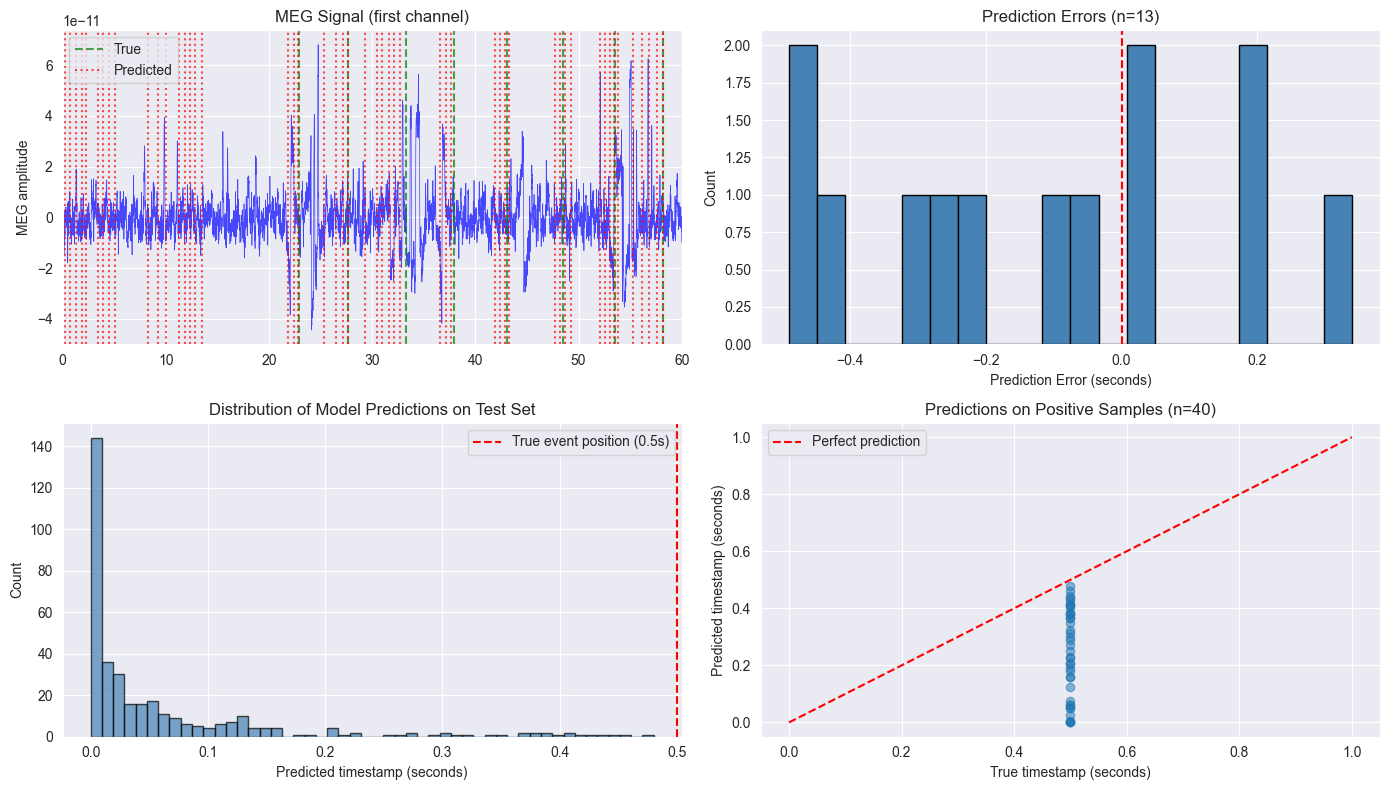


=== SUMMARY ===
Total true events in first 60s: 8
Total predicted events: 51
Precision (rough): 6.38


In [11]:
# Plot with debug info even if no predictions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# First 60 seconds of MEG data (first channel)
raw_subset = raw.copy().crop(0, 60).pick_channels([raw.ch_names[0]])
data, times = raw_subset[:, :]
axes[0, 0].plot(times, data[0], 'b-', alpha=0.7, linewidth=0.5)
axes[0, 0].set_ylabel('MEG amplitude')
axes[0, 0].set_title('MEG Signal (first channel)')

# Mark events
true_in_range = fix_cross_start[(fix_cross_start >= 0) & (fix_cross_start <= 60)]
for t in true_in_range:
    axes[0, 0].axvline(x=t, color='g', linestyle='--', alpha=0.7, label='True' if t == true_in_range[0] else '')

for t in predicted_starts:
    axes[0, 0].axvline(x=t, color='r', linestyle=':', alpha=0.7, label='Predicted' if t == predicted_starts[0] else '')

axes[0, 0].legend()
axes[0, 0].set_xlim(0, 60)

# Histogram of errors (only if we have predictions)
if len(predicted_starts) > 0 and len(true_in_range) > 0:
    errors = []
    for pred in predicted_starts:
        nearest_true = min(true_in_range, key=lambda x: abs(x - pred))
        if abs(pred - nearest_true) < 0.5:
            errors.append(pred - nearest_true)

    axes[0, 1].hist(errors, bins=20, color='steelblue', edgecolor='black')
    axes[0, 1].axvline(x=0, color='r', linestyle='--')
    axes[0, 1].set_xlabel('Prediction Error (seconds)')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title(f'Prediction Errors (n={len(errors)})')
else:
    axes[0, 1].text(0.5, 0.5, f'No predictions\nTrue events: {len(true_in_range)}\nPredicted: {len(predicted_starts)}',
                    ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_title('No Predictions to Show')

# Plot model predictions distribution
axes[1, 0].hist(y_pred_test, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0.5, color='r', linestyle='--', label='True event position (0.5s)')
axes[1, 0].set_xlabel('Predicted timestamp (seconds)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Distribution of Model Predictions on Test Set')
axes[1, 0].legend()

# Plot prediction vs true for positive test samples
test_positive_mask = y_test > 0
if np.sum(test_positive_mask) > 0:
    axes[1, 1].scatter(y_test[test_positive_mask], y_pred_test[test_positive_mask], alpha=0.5)
    axes[1, 1].plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
    axes[1, 1].set_xlabel('True timestamp (seconds)')
    axes[1, 1].set_ylabel('Predicted timestamp (seconds)')
    axes[1, 1].set_title(f'Predictions on Positive Samples (n={np.sum(test_positive_mask)})')
    axes[1, 1].legend()
else:
    axes[1, 1].text(0.5, 0.5, 'No positive samples in test set', ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('No Positive Test Samples')

plt.tight_layout()
plt.show()

# Print summary
print("\n=== SUMMARY ===")
print(f"Total true events in first 60s: {len(true_in_range)}")
print(f"Total predicted events: {len(predicted_starts)}")
if len(predicted_starts) > 0 and len(true_in_range) > 0:
    print(f"Precision (rough): {len(predicted_starts)/max(1, len(true_in_range)):.2f}")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


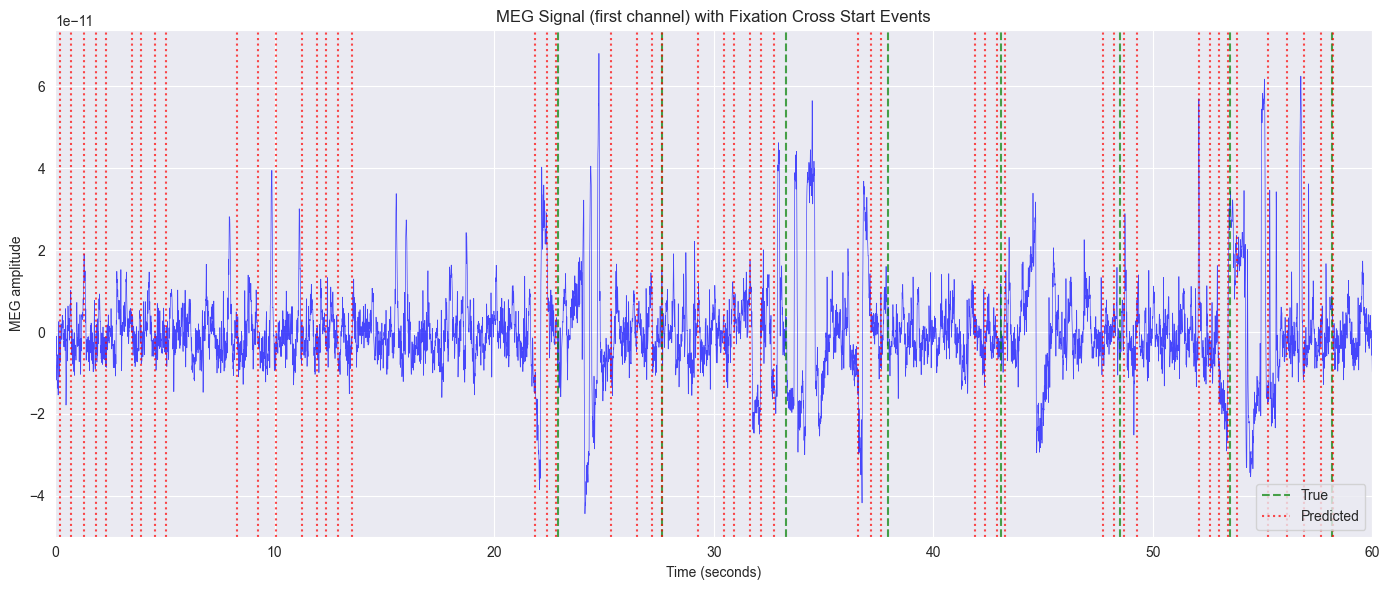


True events in first 60s: 8
Predicted events: 51


In [12]:
# Single plot: MEG signal with true and predicted events
plt.figure(figsize=(14, 6))

# First 60 seconds of MEG data (first channel)
raw_subset = raw.copy().crop(0, 60).pick_channels([raw.ch_names[0]])
data, times = raw_subset[:, :]
plt.plot(times, data[0], 'b-', alpha=0.7, linewidth=0.5)
plt.ylabel('MEG amplitude')
plt.xlabel('Time (seconds)')
plt.title('MEG Signal (first channel) with Fixation Cross Start Events')

# Mark true events
true_in_range = fix_cross_start[(fix_cross_start >= 0) & (fix_cross_start <= 60)]
for t in true_in_range:
    plt.axvline(x=t, color='g', linestyle='--', alpha=0.7, linewidth=1.5,
                label='True' if t == true_in_range[0] else '')

# Mark predicted events
for t in predicted_starts:
    plt.axvline(x=t, color='r', linestyle=':', alpha=0.7, linewidth=1.5,
                label='Predicted' if t == predicted_starts[0] else '')

plt.legend()
plt.xlim(0, 60)
plt.tight_layout()
plt.show()

# Print summary
print(f"\nTrue events in first 60s: {len(true_in_range)}")
print(f"Predicted events: {len(predicted_starts)}")